In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('grayscale')
plt.rc("figure", figsize=(16, 5))

In [5]:
df = pd.read_csv('nyc_taxi.csv', index_col='timestamp', parse_dates=True)
df.head()

,value
timestamp,
2014-07-01 00:00:00,10844
2014-07-01 00:30:00,8127
2014-07-01 01:00:00,6210
2014-07-01 01:30:00,4656
2014-07-01 02:00:00,3820


<Axes: xlabel='timestamp'>

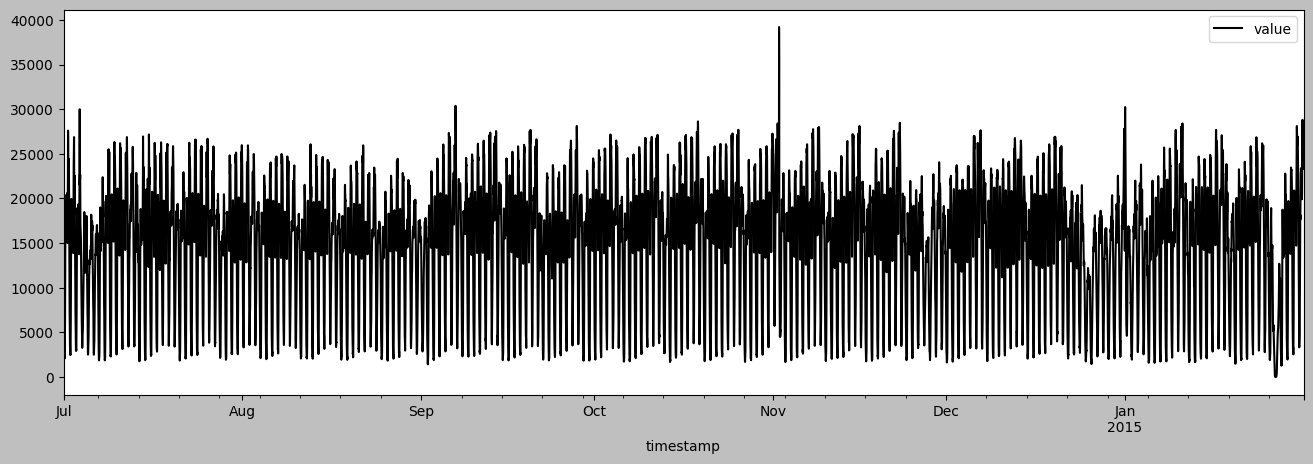

In [6]:
df.plot()

In [7]:
df.index.freq = '30min'

In [8]:
df.index

DatetimeIndex(['2014-07-01 00:00:00', '2014-07-01 00:30:00',
               '2014-07-01 01:00:00', '2014-07-01 01:30:00',
               '2014-07-01 02:00:00', '2014-07-01 02:30:00',
               '2014-07-01 03:00:00', '2014-07-01 03:30:00',
               '2014-07-01 04:00:00', '2014-07-01 04:30:00',
               ...
               '2015-01-31 19:00:00', '2015-01-31 19:30:00',
               '2015-01-31 20:00:00', '2015-01-31 20:30:00',
               '2015-01-31 21:00:00', '2015-01-31 21:30:00',
               '2015-01-31 22:00:00', '2015-01-31 22:30:00',
               '2015-01-31 23:00:00', '2015-01-31 23:30:00'],
              dtype='datetime64[ns]', name='timestamp', length=10320, freq='30min')

<Axes: xlabel='timestamp'>

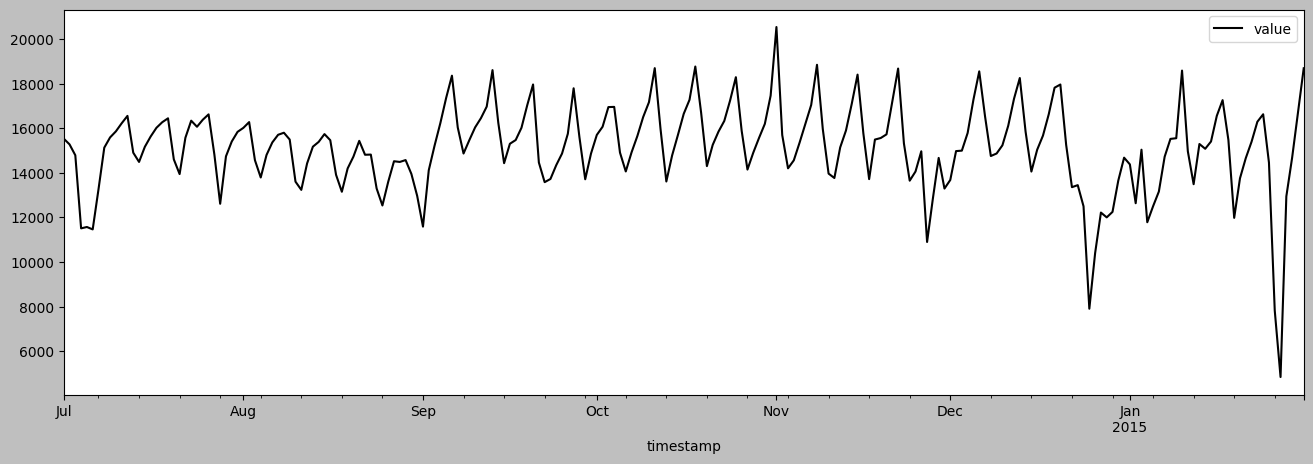

In [ ]:
df.resample('D').mean().plot()

In [15]:
df_resampled = df.resample('D').mean()

# known outliers
nyc_dates =  [
        "2014-11-01",
        "2014-11-27",
        "2014-12-25",
        "2015-01-01",
        "2015-01-27"
]
known_outliers = df_resampled.loc[nyc_dates]
 

In [11]:
def plot_outliers(outliers, data, method='KNN', halignment='right', valignment='bottom', labels=False):
    
    fig, ax = plt.subplots(figsize=(10, 6))
        
    data.plot(ax=ax, alpha=0.6)
    
    # Plot outliers
    if labels:
        outliers.plot(ax=ax, style='rx', markersize=8, legend=False)
        
        # Add text labels for each outlier
        for idx, value in outliers['value'].items():
            ax.text(idx, value, f'{idx.date()}', 
                   horizontalalignment=halignment, 
                   verticalalignment=valignment)
    else:
        outliers.plot(ax=ax, style='rx', legend=False)
    
    ax.set_title(f'NYC Taxi - {method}')
    ax.set_xlabel('date')
    ax.set_ylabel('# of passengers')
    ax.legend(['nyc taxi', 'outliers'])
    
    plt.tight_layout()
    plt.show()

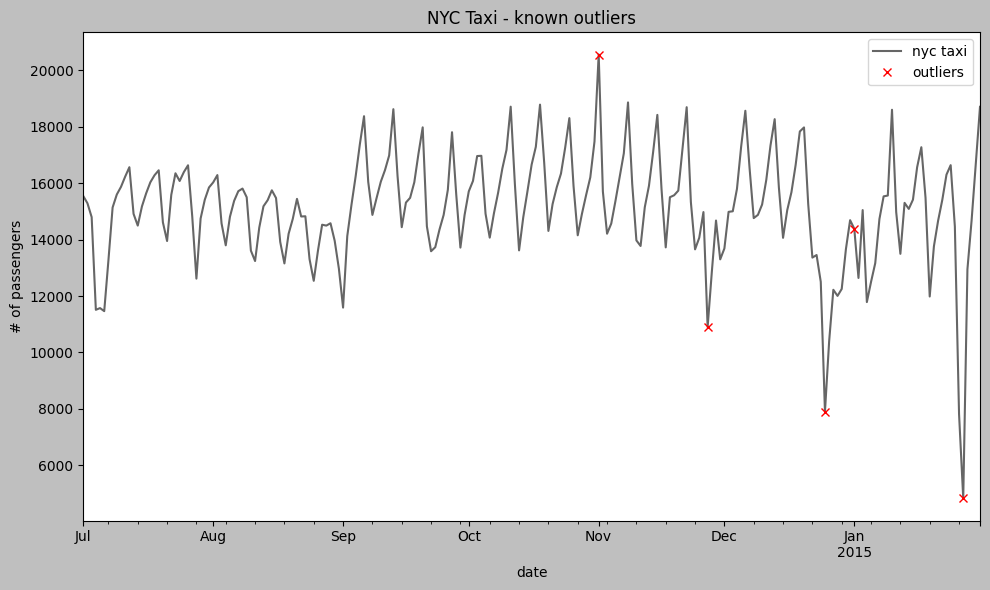

In [16]:
plot_outliers(known_outliers, df_resampled, "known outliers")

In [14]:
!uv pip install seaborn

Using Python 3.12.1 environment at: /workspaces/TechCatalyst_DE_2025/env
Resolved 15 packages in 819ms                                        
░░░░░░░░░░░░░░░░░░░░ [0/1] Installing wheels...                                 warning: Failed to hardlink files; falling back to full copy. This may lead to degraded performance.
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 1 package in 1.38s                                
 + seaborn==0.13.2


<Axes: ylabel='Count'>

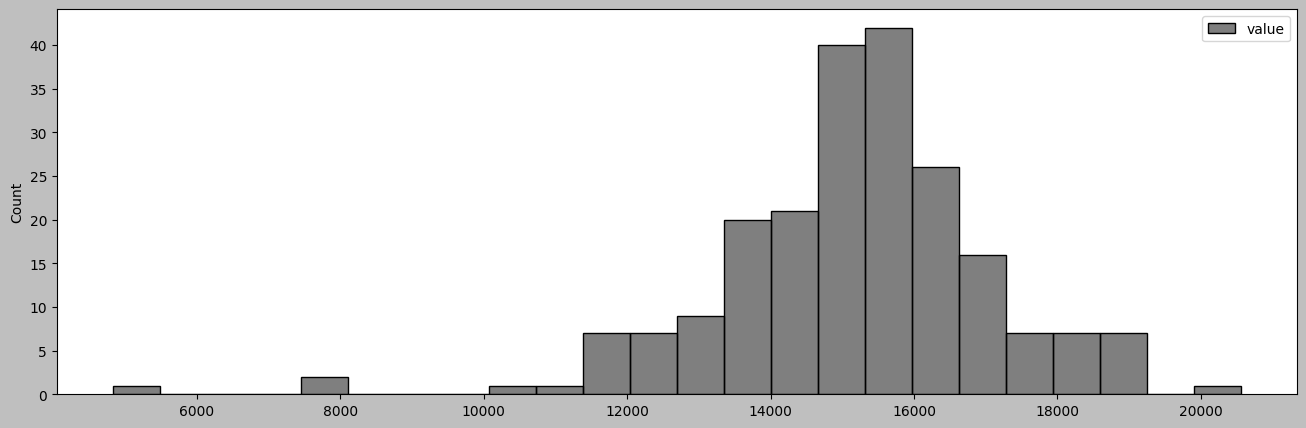

In [17]:
import seaborn as sns

sns.histplot(df_resampled)

<Axes: >

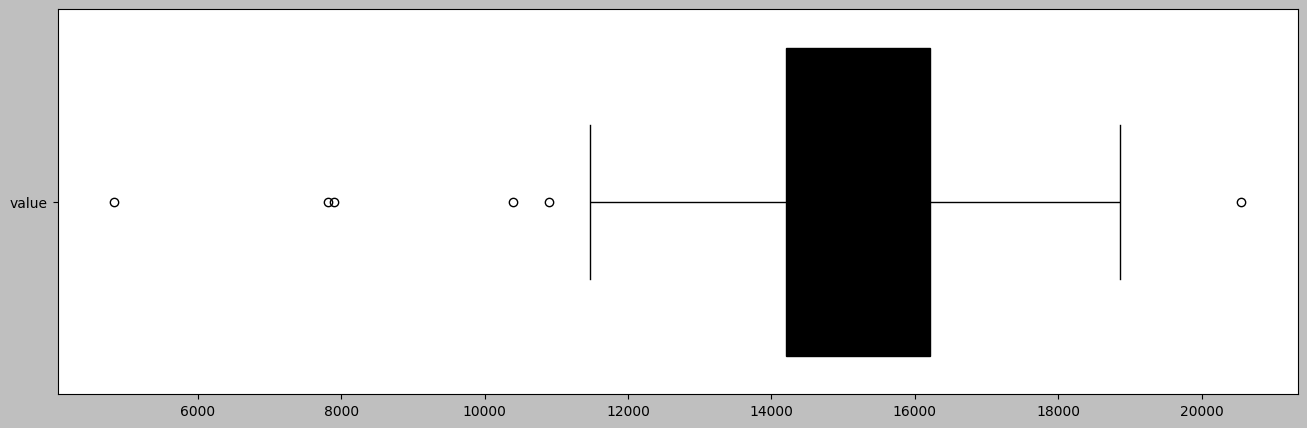

In [18]:
sns.boxplot(df_resampled, orient='h')

<Axes: >

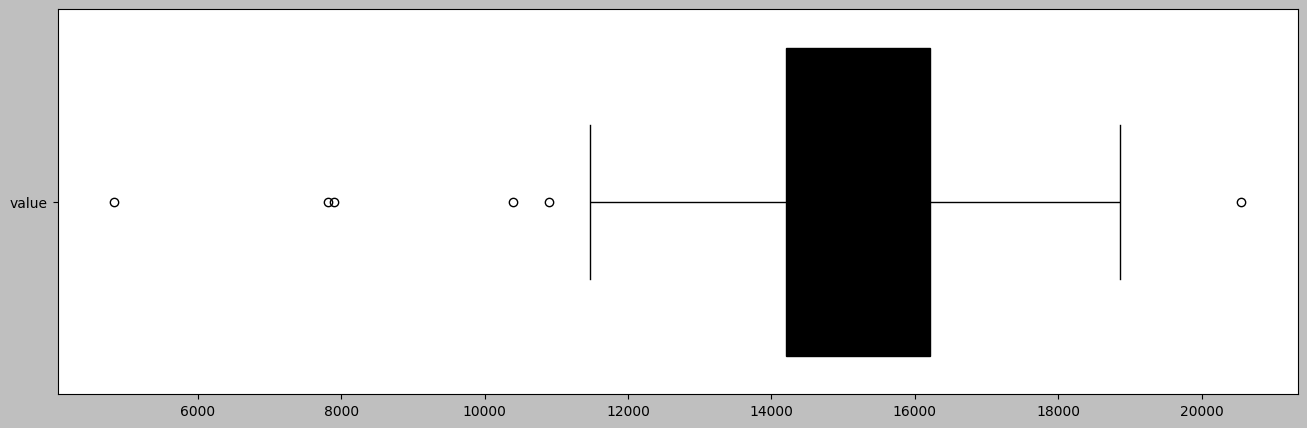

In [19]:
import numpy as np

sns.boxplot(df_resampled, orient='h')

In [20]:
!uv pip install pyod

Using Python 3.12.1 environment at: /workspaces/TechCatalyst_DE_2025/env
Resolved 18 packages in 529ms                                        
⠙ Preparing packages... (0/3)                                                   
⠙ Preparing packages... (0/3)--------------     0 B/15.76 MiB           
⠙ Preparing packages... (0/3)-------------- 16.00 KiB/15.76 MiB         
⠙ Preparing packages... (0/3)-------------- 16.00 KiB/15.76 MiB         
numba                ------------------------------     0 B/3.71 MiB
⠙ Preparing packages... (0/3)-------------- 16.00 KiB/15.76 MiB         
numba                ------------------------------ 14.95 KiB/3.71 MiB
⠙ Preparing packages... (0/3)-------------- 16.00 KiB/15.76 MiB         
numba                ------------------------------ 14.95 KiB/3.71 MiB
⠙ Preparing packages... (0/3)-------------- 16.00 KiB/15.76 MiB         
numba                ------------------------------ 14.95 KiB/3.71 MiB
⠙ Preparing packages... (0/3)-------------- 16.00 KiB/15

In [22]:
from pyod.models.knn import KNN
from pyod.models.iforest import IForest

In [25]:
iforest = IForest(contamination=0.03)
iforest.fit(df_resampled)
iforest_pred = pd.Series(iforest.predict(df_resampled), index=df_resampled.index)

/workspaces/TechCatalyst_DE_2025/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


In [26]:
iforest_pred

timestamp
2014-07-01    0
2014-07-02    0
2014-07-03    0
2014-07-04    0
2014-07-05    0
             ..
2015-01-27    1
2015-01-28    0
2015-01-29    0
2015-01-30    0
2015-01-31    0
Freq: D, Length: 215, dtype: int64

In [28]:
iforest_pred[iforest_pred == 1]

timestamp
2014-11-01    1
2014-11-08    1
2014-11-27    1
2014-12-25    1
2014-12-26    1
2015-01-26    1
2015-01-27    1
dtype: int64

In [29]:
iforest_outliers = iforest_pred[iforest_pred == 1]
iforest_outliers = df_resampled.loc[iforest_outliers .index]

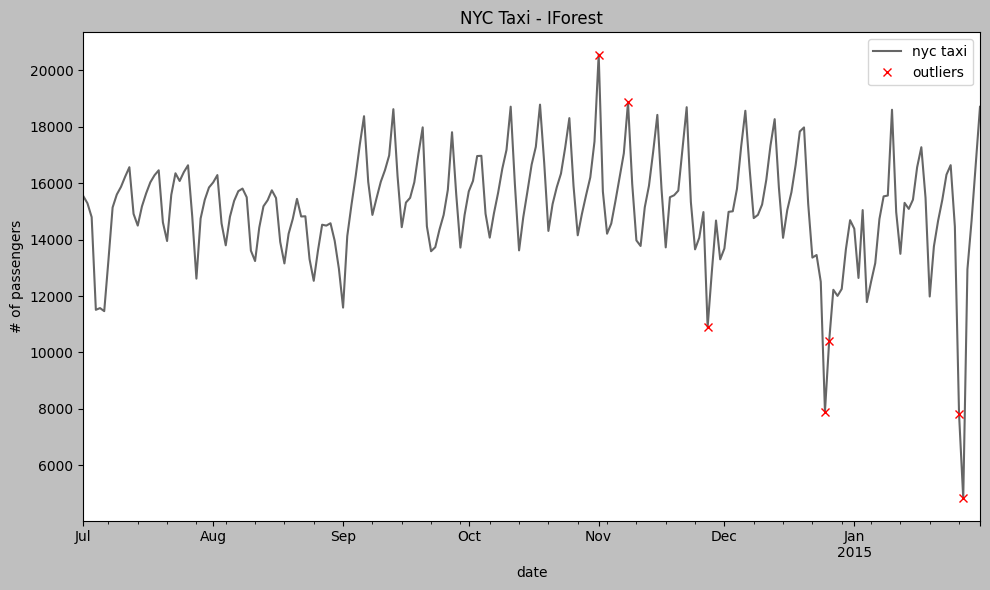

In [30]:
plot_outliers(iforest_outliers, df_resampled, "IForest")